In [1]:
#comparing synaptic efficacy in AN network model   Fig3E, 3F, FigS7,S8,S9, S16B, S16C

import traceback


import math
from scipy.signal import find_peaks
from scipy.signal import periodogram
from scipy import signal
import scipy


import shutil

import numpy as np
import pandas as pd

import gc


from scipy.integrate import odeint

import scipy.stats as st
import itertools

from datetime import datetime

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

from statannot import add_stat_annotation
import os
import sys

sys.path.append('../')
sys.path.append('../anmodel')

import anmodel

import pickle

sns.set()
sns.set_style("ticks") 
np.set_printoptions(threshold=1000)

fs = 20
fs_l = 15

OK
OK


In [2]:
class eval_wave_lr:
    def __init__(self, NE, NI, T, Tp, dt, v_off, drc_neu, drc_syn, tbs):
        self.N = NE + NI
        self.NE = NE
        self.NI = NI
     
        self.tbs = int(T/Tp)# tbs #100 # int(T/Tp)
        self.T = T
        self.Tp=Tp
        self.dt = dt
        self.drc_neu = drc_neu
        self.drc_syn = drc_syn
#         self.th_p = pars_lr["th_p"]
#         self.th_d = pars_lr["th_d"]
#         self.df_np = np.zeros((int((T-v_off)/T_w),11))
        self.x= np.arange(0,tbs*Tp,dt)/1000
    
    def v_of_exp(self, n, ex):
        ex_in = ex+self.ex_diff
        for tb in range(self.tbs):
            v_file = self.drc_neu+ "ex"+str(ex)+"_"+"ex_in"+str(ex_in)+"_"+"N"+str(n)+"_"+str(tb)+".bin" 
            f2= open(v_file, "rb")
            rectype = np.dtype(np.float64)
            v_tb = np.fromfile(f2, dtype=rectype)
            if tb==0:
                v=v_tb
            else:
                v=np.append(v, v_tb)
            f2.close()
        return v
    
    def rho_of_exp(self, pre_syn, n):
        
        for tb in range(self.tbs):
            rho_file = self.drc_syn+"rho"+str(pre_syn)+"-"+str(n)+"_"+str(tb)+".bin"
            frho= open(rho_file, "rb")
            rectype = np.dtype(np.float64)
            rho_tb = np.fromfile(frho, dtype=rectype)
            if tb==0:
                rho=rho_tb
            else:
                rho=np.append(rho, rho_tb)
            frho.close()
        return rho
    
    def ave_rho(self, N,  start):
        try:
            v_file = self.drc_neu +"N"+str(0)+"_"+str(0)+".bin" 
            f2= open(v_file, "rb")
            rectype = np.dtype(np.float64)
            v_tb = np.fromfile(f2, dtype=rectype)
            dt = round(self.Tp/v_tb.shape[0],4)
            print("dt_calc", dt)
#             print("ex {}, dt{}".format(ex, dt))
#             self.x = np.arange(0, self.T, dt)/1000
        except:
            print("dt_calc_Error")
            traceback.print_exc()
        rho_m_li = np.empty(0)
        for n in range(N):
            for s in range(N):
                cpre_file = self.drc_syn+"cpre"+str(s)+"-"+str(n)+"_"+str(0)+".bin"
                if os.path.exists(cpre_file):
                    rho = self.rho_of_exp(s, n)
                    rho_m = np.mean(rho[int(start/dt):])
                    rho_m_li = np.append(rho_m_li, rho_m)
        return np.mean(rho_m_li)
    
    
    def ave_rho2(self, N,  start):
        try:
            v_file = self.drc_neu +"N"+str(0)+"_"+str(0)+".bin" 
            f2= open(v_file, "rb")
            rectype = np.dtype(np.float64)
            v_tb = np.fromfile(f2, dtype=rectype)
            dt = round(self.Tp/v_tb.shape[0],4)
            print("dt_calc", dt)
#             print("ex {}, dt{}".format(ex, dt))
#             self.x = np.arange(0, self.T, dt)/1000
        except:
            print("dt_calc_Error")
            traceback.print_exc()
        syN=0
        for n in range(N):
            for s in range(N):
                cpre_file = self.drc_syn+"cpre"+str(s)+"-"+str(n)+"_"+str(0)+".bin"
                if os.path.exists(cpre_file):
                    syN+=1
                    
        rho_m_li = np.zeros((syN, int((self.T-start)/dt)))
        c=0
        for n in range(N):
            for s in range(N):
                cpre_file = self.drc_syn+"cpre"+str(s)+"-"+str(n)+"_"+str(0)+".bin"
                if os.path.exists(cpre_file):
                    rho = self.rho_of_exp(s, n)
                    rho_m_li[c]=rho[int(start/dt):]
                    c+=1
#                     rho_m = np.mean(rho[int(start/dt):])
#                     rho_m_li = np.append(rho_m_li, rho_m)
        return rho_m_li
    
    
    def peak_value(self, N, ex, start_T, T_w):
        
        start_num = int(start_T/Tp)
        tbs = int((T_w-start_T)/self.Tp)
   
        mean_peaks = np.zeros(N, dtype = "float32")
        for n in range(N):
            
                for tb in range(tbs):
                    v_file = self.drc_neu+ "ex"+str(ex)+"_"+"ex_in"+str(ex_in)+"_"+"N"+str(n)+"_"+str(start_num+tb)+".bin" 
                    f2= open(v_file, "rb")
                    rectype = np.dtype(np.float64)
                    v_tb = np.fromfile(f2, dtype=rectype)
                    if tb==0:
                        v=v_tb
                    else:
                        v=np.append(v, v_tb)
                    f2.close()
                    
                peak_vs = self.peak_detect(v[int(start_T/self.dt):int(T_w/self.dt-start_T/self.dt)])
                mean_peaks[n] = np.mean[peak_vs]
        mean_peak = np.mean(mean_peaks)
        return mean_pwak
    
    def raster(self, N, ex, start_T, T_w):
        
        start_num = int(start_T/Tp)
        tbs = int((T_w-start_T)/self.Tp)
   
        spts = np.zeros((N, int((T_w-start_T)/self.dt)), dtype = "int8")
        for n in range(N):
            try:
                for tb in range(tbs):
                    v_file = self.drc_neu+ "ex"+str(ex)+"_"+"ex_in"+str(ex_in)+"_"+"N"+str(n)+"_"+str(start_num+tb)+".bin" 
                    f2= open(v_file, "rb")
                    rectype = np.dtype(np.float64)
                    v_tb = np.fromfile(f2, dtype=rectype)
                    if tb==0:
                        v=v_tb
                    else:
                        v=np.append(v, v_tb)
                    f2.close()
                    
                pattern, maxfre, sp_c, peak_np = self.fre_spike(v[int(start_T/self.dt):int(T_w/self.dt-start_T/self.dt)])
           
                if maxfre!=0 and sp_c!=0:
                    if pattern!= "ERROR" and pattern != "EXCLUDED": 
                    # if pattern == "SWS" or pattern == "SWS_HIGH_FR" or pattern == "AWAKE" or pattern == "AWAKE_HIGH_FR" or pattern == "SWS_FEW_SPIKES" or pattern == "RES":
                        spts[n]= peak_np
            except:
                print("make_sp_np_error")
                traceback.print_exc()
        
        plt.figure(figsize=(23, 10))
#         Lt = int((T_w-start_T)/self.dt)
        x2= np.arange(0, (T_w-start_T), self.dt) #np.arange(0,Lt,1)
        
        #color_set = ['r', 'b', 'k', 'orange', 'c']
        for i in range(spts.shape[0]):
            t_sp = x2[spts[i, :] > 0.5]   # spike times
            plt.plot(t_sp/1000, i*np.ones(len(t_sp)), '.',
                 ms=8, markeredgewidth=0.1, color="black")
        plt.xlabel('Time (sec)',fontsize = fs)
        plt.ylabel('Neuron ID', fontsize = fs)
        #plt.xlim(0, 1)
        plt.xticks(fontsize = fs_l)
        plt.yticks(fontsize = fs_l)
        plt.show()
        

    def calc_spts_100ms(self, N, ex,v_off):
        T_w=100  #ms
        tc = int(self.T/T_w)
        print("step_num", tc)
        off_c=int(v_off/self.Tp)
        w_c=int(T_w/self.Tp)
        print("w_c", w_c)
#         ex =round(ex,2)
        ex_in = (ex + self.ex_diff)
        sp_sums = np.zeros(tc)
        
        flag=0
        for it in range(tc):
            spts = np.zeros((N, int((T_w)/self.dt)), dtype = "int8")
            for n in range(N):
#                 print("n", n)
#                 try:
                for tb in range(off_c+it*w_c, off_c+(it+1)*w_c):
#                     print("tb", tb)
                    v_file = self.drc_neu+ "ex"+str(ex)+"_"+"ex_in"+str(ex_in)+"_"+"N"+str(n)+"_"+str(int(tb))+".bin" 
                    f2= open(v_file, "rb")
                    rectype = np.dtype(np.float64)
                    v_tb = np.fromfile(f2, dtype=rectype)
                    if tb==off_c+it*w_c:
                        v=v_tb
                    else:
                        v=np.append(v, v_tb)
                    f2.close()
                pattern, maxfre, sp_c, peak_np = self.fre_spike(v)
                
                try:
                    if maxfre!=0 and sp_c!=0:
                        if pattern != "ERROR" and pattern != "EXCLUDED": 
                            spts[n]= peak_np
                except:
                    print("file_Error, cant make DF")
                    traceback.print_exc()
                    flag = 1
#             print(spts.shape)
            total_sps = np.sum(spts)
            sp_sums[it] = total_sps
            
        return sp_sums
    
    def mean_fre(self, N, start):

        spN=np.zeros(N, dtype="int64")
        flag = 0
        for n in range(N):
            for tb in range(self.tbs):
                v_file = self.drc_neu +"N"+str(n)+"_"+str(tb)+".bin" 
                f2= open(v_file, "rb")
                rectype = np.dtype(np.float64)
                v_tb = np.fromfile(f2, dtype=rectype)
                if tb==0:
                    v=v_tb
                else:
                    v=np.append(v, v_tb)
                f2.close()
            pattern, maxfre, sp_c, peak_np = self.fre_spike(v, start)
            spN[n]=sp_c/((self.T-start)/1000)
            if sp_c==0:
                flag=1
                break
        m_fre= np.mean(spN)
#         print("mean spike fre", m_fre)
        return m_fre, flag
            
            
    
    

    def calc_cvs(self, ex, N, T_w, cv_w, moving, moving_cv, v_off):
#         tc =  int((self.T-T_w)/moving+1)
        tc =  int((self.tbs*self.Tp - T_w)/moving+1)
        
        cv_li = np.zeros(tc)
        off_c=int(v_off/self.Tp)
#         ex =round(ex,2)
#         ex_in = round((ex + self.ex_diff), 2)
            
        spts = np.zeros((N, int(self.tbs*self.Tp/self.dt)), dtype = "int8")
        for n in range(N):
            for tb in range(self.tbs):
#                     print("tb", tb)
                v_file = self.drc_neu+ "ex"+str(ex)+"_"+"ex_in"+str(ex_in)+"_"+"N"+str(n)+"_"+str(int(tb))+".bin" 
                f2= open(v_file, "rb")
                rectype = np.dtype(np.float64)
                v_tb = np.fromfile(f2, dtype=rectype)
                if tb==0:
                    v=v_tb
                else:
                    v=np.append(v, v_tb)
                f2.close()
#                         if n<self.NE:
#                             if n==0:
#                                 vm_li = v
#                             else:
#                                 vm_li=np.append(vm_li, v)

            pattern, maxfre, sp_c, peak_np = self.fre_spike(v)
            spts[n]= peak_np
        offset = 0
        for i in range(tc):
            cv = self.calc_cv(N, spts, T_w, offset, cv_w,  moving_cv)
            print("{}, CV:{}/".format(i, cv))
            cv_li[i]=cv
            offset += int(moving/self.dt)
            
        return cv_li
    
  


    
            
    
    def fre_spike(self, v, start):
#         v=v[0:int(T/dt)]
        try:
            dt = round(self.T/v.shape[0],4)
#             print("dt_calc", dt)
#             print("ex {}, dt{}".format(ex, dt))
#             self.x = np.arange(0, self.T, dt)/1000
        except:
            print("dt_calc_Error")
            traceback.print_exc()

        T = int(v.shape[0]*dt-start) #ms
        if np.any(np.isinf(v)) or np.any(np.isnan(v)):
            print("fre_spike: nan")
            return "Exclude", 0, 0, np.zeros(int(T/dt), dtype="int8")
        else:
            wavech = anmodel.analysis.WaveCheck(1000)
            pattern = wavech.pattern(v, T, dt, pr=False)
            detv: np.ndarray = signal.detrend(v)
            max_potential: float = max(detv)
            f, spw = periodogram(detv, fs=1/dt*1000)
            maxamp: float = max(spw)
            nummax: int = spw.tolist().index(maxamp)
            maxfre: float = f[nummax]

            peaks = find_peaks(v[int(start/dt):], height=-20)[0]
#             print(v.shape)
            peak_np = np.zeros(int(T/dt), dtype="int8")
            peak_np[peaks]=1
#             print(peak_np.shape)
            return pattern.name, maxfre, len(peaks), peak_np



    def peak_detect(self, v, start):
#         v=v[0:int(T/dt)]
        try:
            dt = round(self.T/v.shape[0],4)
#             print("dt_calc", dt)
#             print("ex {}, dt{}".format(ex, dt))
#             self.x = np.arange(0, self.T, dt)/1000
        except:
            print("dt_calc_Error")
            traceback.print_exc()

        T = int(v.shape[0]*dt-start) #ms
        if np.any(np.isinf(v)) or np.any(np.isnan(v)):
            print("fre_spike: nan")
            return "Exclude", 0, 0, np.zeros(int(T/dt), dtype="int8")
        else:
            wavech = anmodel.analysis.WaveCheck(1000)
            pattern = wavech.pattern(v, T, dt, pr=False)
            detv: np.ndarray = signal.detrend(v)
            max_potential: float = max(detv)
            f, spw = periodogram(detv, fs=1/dt*1000)
            maxamp: float = max(spw)
            nummax: int = spw.tolist().index(maxamp)
            maxfre: float = f[nummax]


            peaks = find_peaks(v[int(start/dt):], height=-20)[0]
#             print(v.shape)

            peak_vs = v[int(start/dt):][peaks]
          
            return peak_vs
            
            
    

def eva_pv(p):
    if p<0.05 and p>=0.01:
        print("p<0.05, *")
        pstr="*"
    elif p<0.01 and p>=0.001:
        print("p<0.01, **")
        pstr="**"
    elif p<0.001 and p>= 0.0001:
        print("p<0.001, ***")
        pstr="***"
    elif p<0.0001:
        print("p<0.0001, ****")
        pstr="****"
    else:
        print("p>=0.05, ns")
        pstr="ns"
    return pstr

def v_of_exp(drc_neu, n):
        for tb in range(tbs):
            v_file = drc_neu+"N"+str(n)+"_"+str(tb)+".bin" 
            f2= open(v_file, "rb")
            rectype = np.dtype(np.float64)
            v_tb = np.fromfile(f2, dtype=rectype)
            if tb==0:
                v=v_tb
            else:
                v=np.append(v, v_tb)
            f2.close()
        return v
    
def rho_of_exp(drc_syn, pre_syn, n):
        
        for tb in range(tbs):
            rho_file = drc_syn+"rho"+str(pre_syn)+"-"+str(n)+"_"+str(tb)+".bin"
            frho= open(rho_file, "rb")
            rectype = np.dtype(np.float64)
            rho_tb = np.fromfile(frho, dtype=rectype)
            if tb==0:
                rho=rho_tb
            else:
                rho=np.append(rho, rho_tb)
            frho.close()
        return rho

dt_calc 0.05


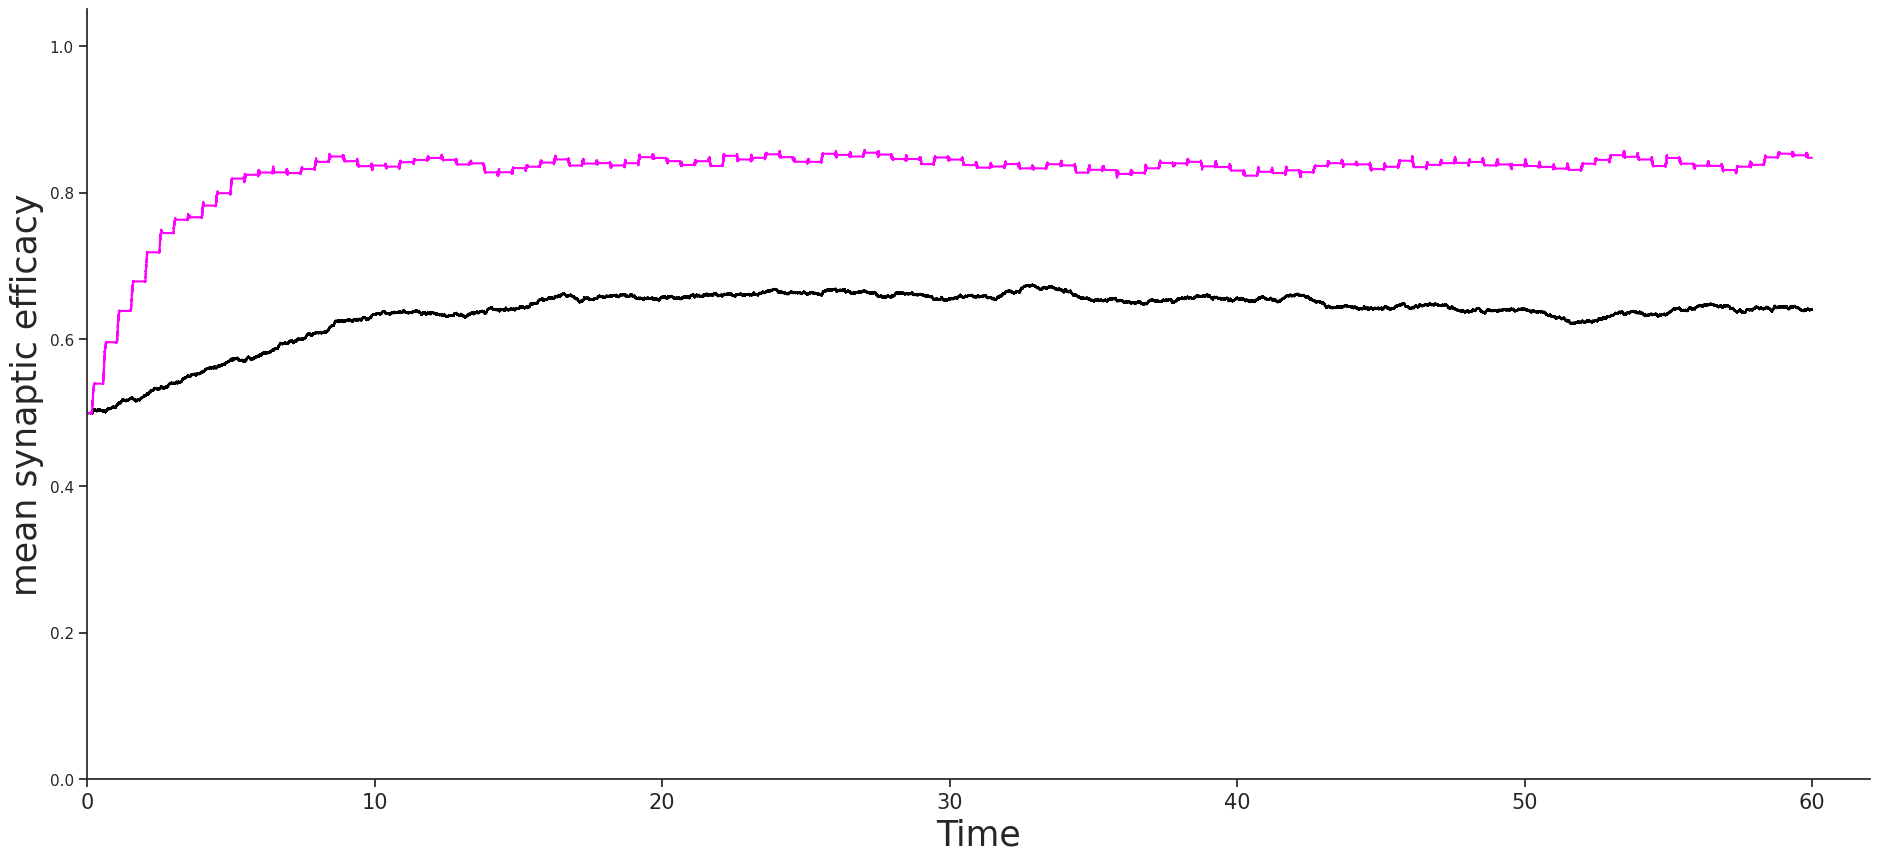

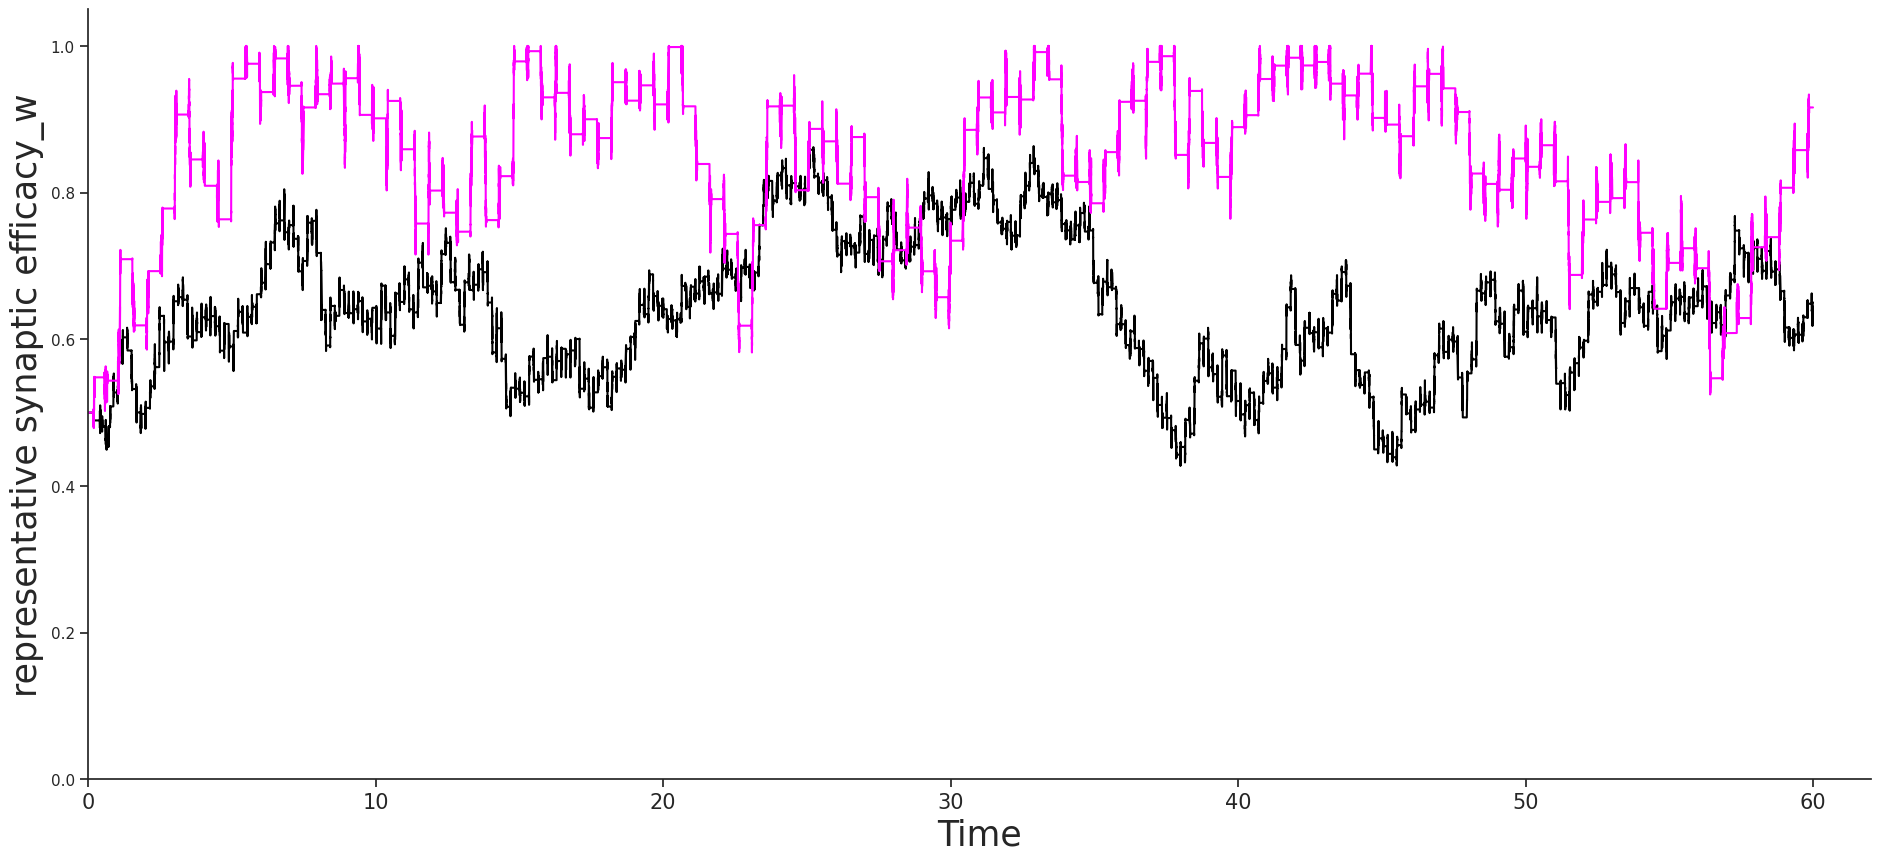

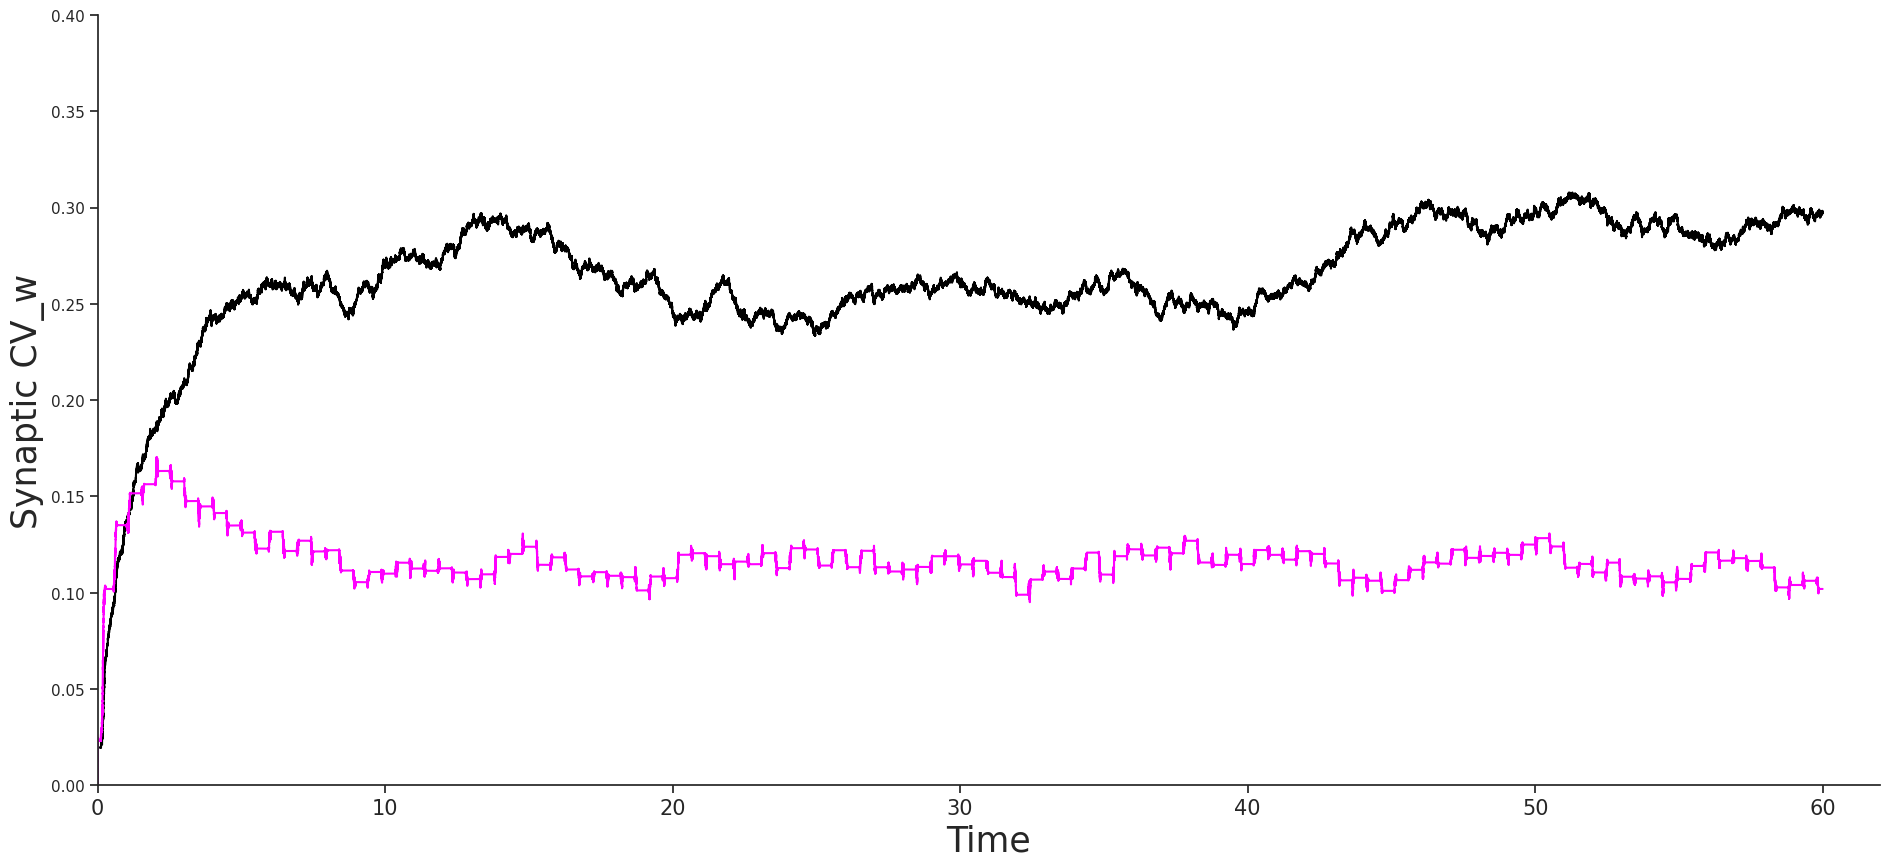

9989

In [4]:

#plot grahh for time change of mean effi and CV of representateive model

rdir = "../AN_network/"
model_pre = "AN"
date_i="2023_4_26_0_2"
ex_w = -0.7
ex_s = -0.4
op="_net_effi"
bifur = "nmdar"
lr = "STDP"
lr_p = "a0.7t50th0.6"



NE = 64
Ip = 20
NI = int(NE*Ip/(100-Ip))
N=NE+NI
cpre_r = 1.0

cpost_r = 1.0
# g_nap_SDs = [0]
con_M = 1.0
con_M_in = 1.0
con_ex_ex = 0.01
con_ex_in = 0.01
con_in_ex = 0.01
con_in_in = 0.01
rho_ini = 0.5
T =  60000#ms
Tp= 1000
dt = 0.05

smin_ampa=0.5
smax_ampa=1.5


init = "r"
seed = 4
con_log = True


start_m = 0  #ms
x = np.arange(0, T, dt)/1000  #sec

v_off = 0 #ms


model_name = model_pre + op + "_"+bifur +"_"+lr +"_w"
model_name_s = model_pre + op +"_"+ bifur +"_"+lr +"_s"

fs = 25
nowdir = os.getcwd()
sdir="../AN_network/net_lr/"


tbs=int(T/Tp)



drc =rdir+"/con_cu_i/{}/NE{}_NI{}/conM{}_conSD{}_conMin{}_conSDin{}/sminampa{}_smaxampa{}/{}_{}/".format(model_name,NE, NI,con_M, con_ex_ex,con_M_in, con_in_in,smin_ampa,smax_ampa,lr,lr_p)
drc_s =rdir+"con_cu_i/{}/NE{}_NI{}/conM{}_conSD{}_conMin{}_conSDin{}/sminampa{}_smaxampa{}/{}_{}/".format(model_name_s,NE, NI,con_M, con_ex_ex,con_M_in, con_in_in,smin_ampa,smax_ampa,lr,lr_p)

    
drc_i = drc + date_i + "/exs/" + str(ex_w) + "/seed_{}/init_{}/T_{}/Tp_{}/".format(seed,init,  T, Tp)
drc_i_s = drc_s + date_i +"/exs/"+ str(ex_s)+ "/seed_{}/init_{}/T_{}/Tp_{}/".format(seed,init,  T, Tp)

drc_neu = drc_i + "neu/"
drc_syn = drc_i + "syn/"
drc_neu_s = drc_i_s + "neu/"
drc_syn_s = drc_i_s + "syn/"

syN=0
for n in range(N):
    for s in range(N):
        cpre_file = drc_syn+"cpre"+str(s)+"-"+str(n)+"_"+str(0)+".bin"
        if os.path.exists(cpre_file):
            syN+=1
            

start = 0

#calc dt
try:
    v_file = drc_neu +"N"+str(0)+"_"+str(0)+".bin" 
    f2= open(v_file, "rb")
    rectype = np.dtype(np.float64)
    v_tb = np.fromfile(f2, dtype=rectype)
    dt = round(Tp/v_tb.shape[0],4)
    print("dt_calc", dt)

except:
    print("dt_calc_Error")
    traceback.print_exc()


#graph for wake
rho_li = np.zeros((syN, int((T-start)/dt)))
c=0
for n in range(N):
    for s in range(N):
        cpre_file = drc_syn+"cpre"+str(s)+"-"+str(n)+"_"+str(0)+".bin"
        if os.path.exists(cpre_file):
            rho = rho_of_exp(drc_syn, s, n)
            rho_li[c]=rho[int(start/dt):]
            c+=1

#graph for sleep
rho_li_s = np.zeros((syN, int((T-start)/dt)))
c=0
for n in range(N):
    for s in range(N):
        cpre_file = drc_syn_s+"cpre"+str(s)+"-"+str(n)+"_"+str(0)+".bin"
        if os.path.exists(cpre_file):
            rho = rho_of_exp(drc_syn_s, s, n)
            rho_li_s[c]=rho[int(start/dt):]
            c+=1
            

plt.figure(figsize=(23, 10))
plt.plot(x, np.mean(rho_li, axis=0), c="black")
plt.plot(x, np.mean(rho_li_s, axis=0), c="magenta")
plt.ylabel("mean synaptic efficacy", fontsize = fs)
plt.xlabel("Time", fontsize = fs)
# plt.yticks(np.arange(0,1.1,0.5), fontsize = fs_l)
plt.xticks(fontsize = fs_l)
plt.ylim(0,1.05)
plt.xlim(0,62)
# plt.ylim(0.6, 0.8)
# plt.xlim(20,26)
ax = plt.gca()
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
# plt.savefig("AN_{}_{}_N{}_{}_{}_mean_rho.SVG".format(date_i, bifur, N, lr, lr_p))
plt.show()


#             print("{}, rho_m_w {}".format(date_i, rho_m_w))
plt.figure(figsize=(23, 10))
plt.plot(x, rho_li[1], c="black")
plt.plot(x, rho_li_s[1], c="magenta")
plt.ylabel("representative synaptic efficacy_w", fontsize = fs)
plt.xlabel("Time", fontsize = fs)
# plt.yticks(np.arange(0,1.1,0.5), fontsize = fs_l)
plt.xticks(fontsize = fs_l)
plt.ylim(0,1.05)
plt.xlim(0,62)
# plt.xlim(20,26)


ax = plt.gca()
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
# plt.savefig("AN_{}_{}_N{}_{}_{}_repre_rho.SVG".format(date_i, bifur, N, lr, lr_p))
plt.show()



plt.figure(figsize=(23, 10))
plt.plot(x, np.std(rho_li, axis=0)/np.mean(rho_li,axis=0), c="black")
plt.plot(x, np.std(rho_li_s, axis=0)/np.mean(rho_li_s,axis=0), c="magenta")
plt.ylabel("Synaptic CV_w", fontsize = fs)
plt.xlabel("Time", fontsize = fs)
# plt.yticks(np.arange(0,0.155,0.075), fontsize = fs_l)
plt.xticks(fontsize = fs_l)
plt.ylim(0,0.4)
plt.xlim(0,62)
# plt.xlim(20,26)
# plt.ylim(0.05, 0.3)

ax = plt.gca()
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
# plt.savefig("AN_{}_{}_N{}_{}_{}_CV_w.SVG".format(date_i, bifur, N, lr, lr_p))
plt.show()



del rho_li
del rho_li_s
gc.collect()


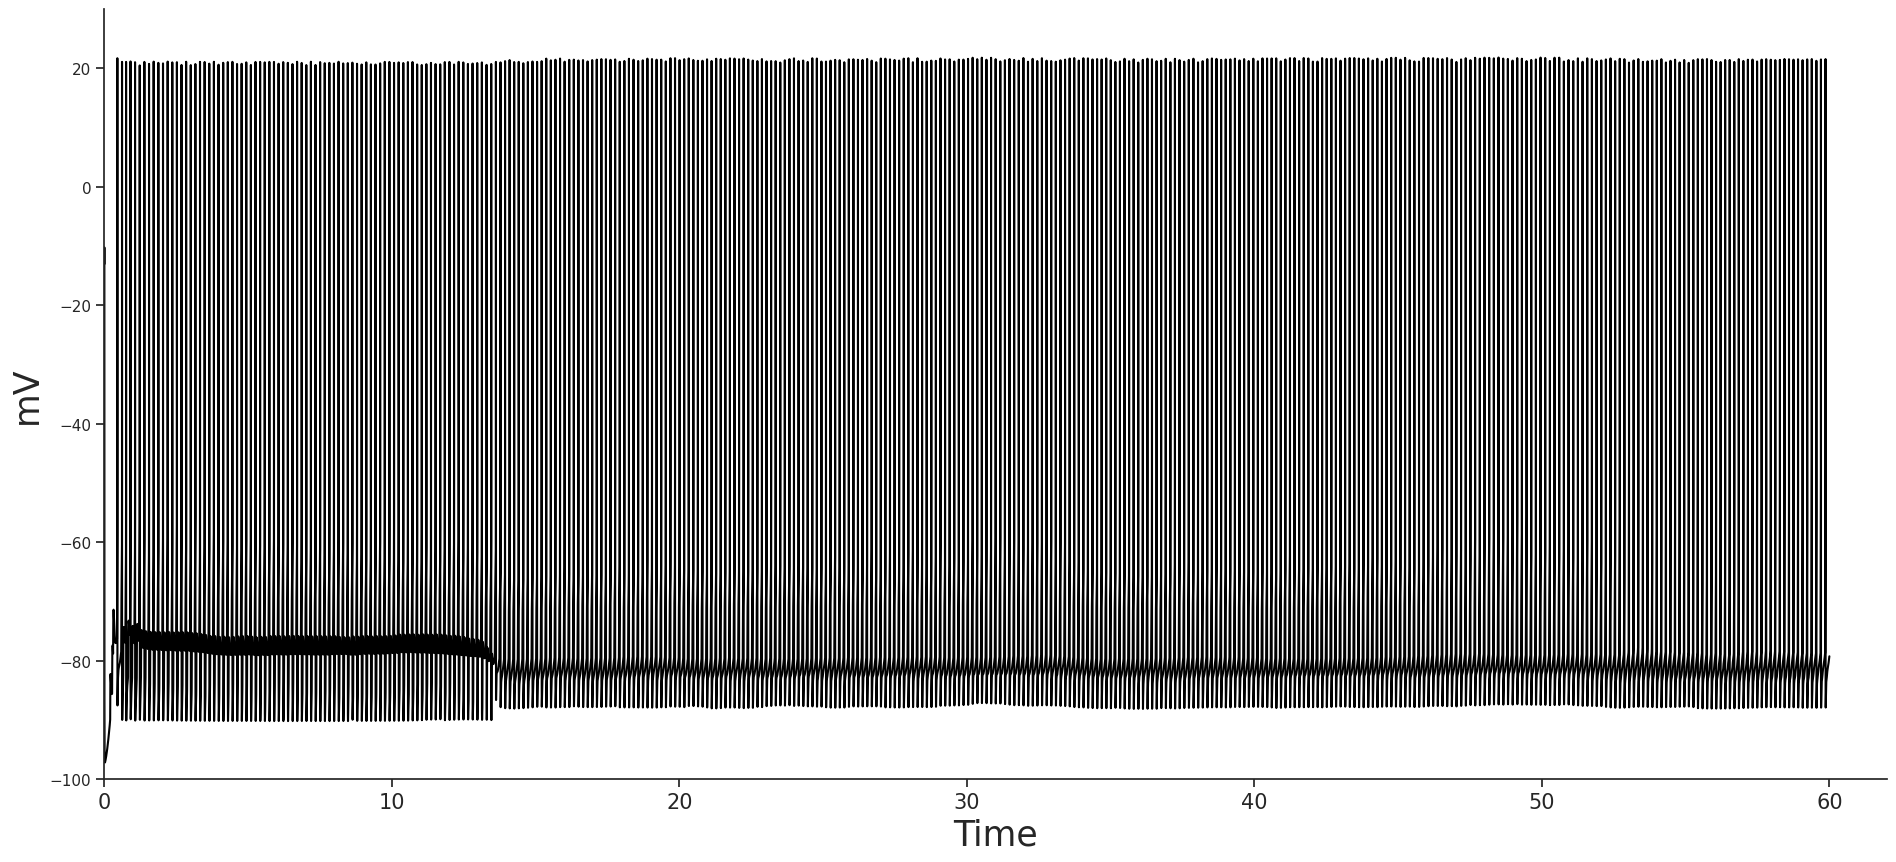

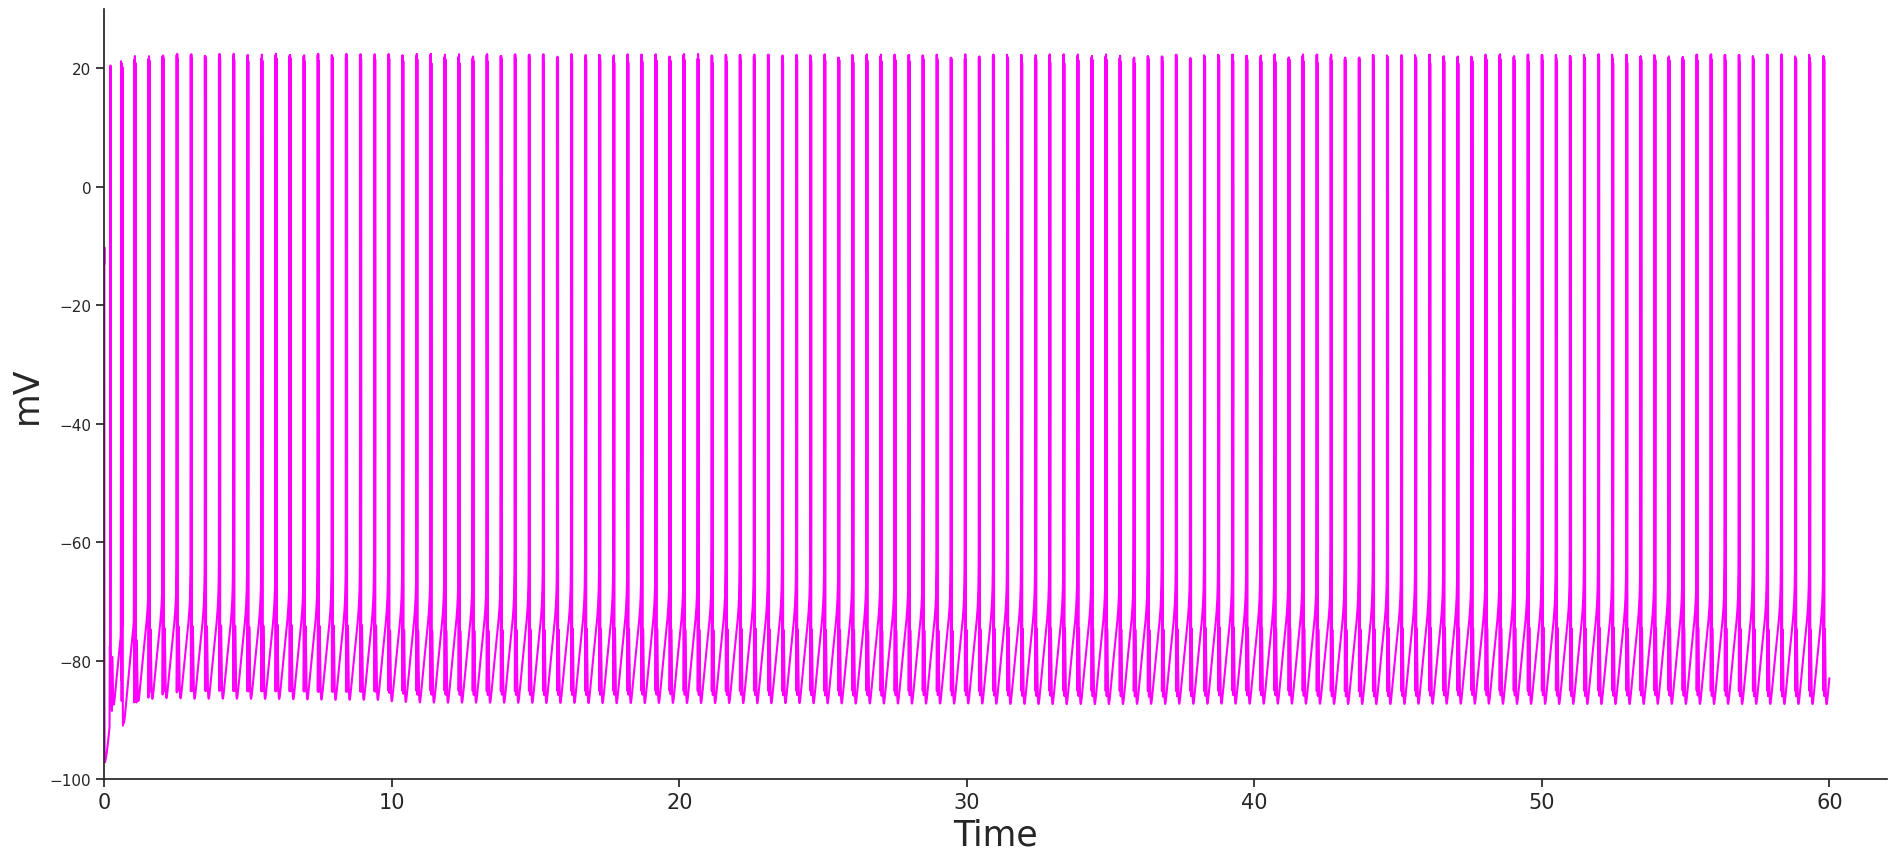

3432

In [5]:
n=29
v=v_of_exp(drc_neu,  n)

plt.figure(figsize=(23, 10))
# plt.plot(x, np.mean(rho_li, axis=0), c="black")
plt.plot(x, v, c="black")
plt.ylabel("mV", fontsize = fs)
plt.xlabel("Time", fontsize = fs)
# plt.yticks(np.arange(0,1.1,0.5), fontsize = fs_l)
plt.xticks(fontsize = fs_l)
plt.ylim(-100,30)
plt.xlim(0,62)
# plt.xlim(20,26)

ax = plt.gca()
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
# plt.savefig("AN_{}_{}_N{}_{}_{}_wave_repre_w_all.SVG".format(date_i, bifur, N, lr, lr_p))
plt.show()
del v
gc.collect()

v=v_of_exp(drc_neu_s,  n)
plt.figure(figsize=(23, 10))
# plt.plot(x, np.mean(rho_li, axis=0), c="black")
plt.plot(x, v, c="magenta")
plt.ylabel("mV", fontsize = fs)
plt.xlabel("Time", fontsize = fs)
# plt.yticks(np.arange(0,1.1,0.5), fontsize = fs_l)
plt.xticks(fontsize = fs_l)
# plt.ylim(0,1.05)
plt.ylim(-100,30)
# plt.xlim(20,26)
plt.xlim(0,62)

ax = plt.gca()
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
# plt.savefig("AN_{}_{}_N{}_{}_{}_wave_repre_s_all.SVG".format(date_i, bifur, N, lr, lr_p))
plt.show()
del v
gc.collect()

In [4]:
#make total files 

rdir = "../AN_network/"
xl_ori =rdir+"/net_lr_data.xlsx"
df_ori = pd.read_excel(xl_ori, engine="openpyxl")
dates_ori = df_ori["date_i"]

model_pre = "AN"
op="_net_effi"
bifur = "nmdar"
lr = "STDP"
lr_p = "a0.7t50th0.6"


NE = 64
Ip = 20
NI = int(NE*Ip/(100-Ip))
N=NE+NI
cpre_r = 1.0

cpost_r = 1.0
# g_nap_SDs = [0]
con_M = 1.0
con_M_in = 1.0
con_ex_ex = 0.01
con_ex_in = 0.01
con_in_ex = 0.01
con_in_in = 0.01
rho_ini = 0.5
T =  60000#ms
Tp= 10000
dt = 0.05
# ex= -0.3
# ex_in= ex
smin_ampa=0.5
smax_ampa=1.5

# ex_diff = (ex_in - ex)
init = "r"
seed = 4
con_log = True
# ori_files =True
# time = np.arange(0, T , dt)/1000 #s
model_name = model_pre + op + "_"+bifur +"_"+lr +"_w"
model_name_s = model_pre + op + "_"+bifur +"_"+lr +"_s"

sdir = rdir+"/net_lr/"
T_dir = sdir + "{}{}_{}_N{}_{}_{}/".format(model_pre, op, bifur, NE+NI, lr, lr_p)
print(T_dir)
try:
    os.makedirs(T_dir)
except FileExistsError:
    print("{} is already exist".format(T_dir)) 

savef_T = T_dir +"wake.csv" 
savef_Ts = T_dir +"sleep.csv"

savef_T_cv = T_dir +"wake_cv.csv" 
savef_T_cv_s = T_dir +"sleep_cv.csv"
 
if con_log==False:
    drc =rdir+"/con_cu_i/{}/param_{}/rhoini{}/NE{}_NI{}/con_th{}_{}_{}_{}/g_nap_{}/gabac_{}/seed_{}/init_{}/T_{}/Tp_{}/dt_{}/{}_{}_{}/".format(model_name,i,rho_ini,NE,NI, con_ex_ex,con_ex_in,con_in_ex,con_in_in, SD,gaba_c,  seed,init,  T, Tp,dt,lr,lr_p,n)
else:
    drc =rdir+"/con_cu_i/{}/NE{}_NI{}/conM{}_conSD{}_conMin{}_conSDin{}/sminampa{}_smaxampa{}/{}_{}/".format(model_name,NE, NI,con_M, con_ex_ex,con_M_in, con_in_in,smin_ampa,smax_ampa,lr,lr_p)
    drc_s =rdir+"/con_cu_i/{}/NE{}_NI{}/conM{}_conSD{}_conMin{}_conSDin{}/sminampa{}_smaxampa{}/{}_{}/".format(model_name_s,NE, NI,con_M, con_ex_ex,con_M_in, con_in_in,smin_ampa,smax_ampa,lr,lr_p)


date_is = os.listdir(drc)
print(date_is)
fre_w_li = []
fre_s_li = []
effi_w_li=[]
effi_s_li=[]
cv_w_li=[]
cv_s_li=[]
diff_li = []
dates_ana=[]
# for n, date_i in enumerate(date_is):
c=0
for n, date_i in enumerate(dates_ori):
#     if bifur =="_cav":
#         if date_i == "2023_3_29_0_0" or date_i=="2023_4_27_0_4" or date_i=="2023_6_30_4_2" or date_i=="2023_4_16_0_6":
#             continue
#
    
    savedir =  drc + date_i + "/"
    savedir_s =  drc_s + date_i +"/"
    savef=savedir + "wake.csv"
    savef_s=savedir_s + "sleep.csv"
    
    savef_cv=savedir + "wake_cv.csv"
    savef_cv_s=savedir_s + "sleep_cv.csv"
    
    fref=savedir + "m_wake_fre.csv"
    fref_s=savedir_s + "m_sleep_fre.csv"
    
    
    if not os.path.exists(fref) or not os.path.exists(fref_s):
            continue
        
    fre_w = np.genfromtxt(fref, delimiter=',', dtype=np.float64)
    fre_s = np.genfromtxt(fref_s, delimiter=',', dtype=np.float64)

    
    if fre_w==-1 or fre_s==-1 or np.abs(fre_w-fre_s)>2.0:
            continue
            
    if not os.path.exists(savef) or not os.path.exists(savef_s) or not os.path.exists(savef_cv) or not os.path.exists(savef_cv_s):
        continue


    effis = np.genfromtxt(savef, delimiter=',', dtype=np.float64)

    if not os.path.exists(savef_T):
        np.savetxt(savef_T, effis, delimiter=',')
    elif c==0 and os.path.exists(savef_T):
        np.savetxt(savef_T, effis, delimiter=',')  #create new file 

    elif c!=0 and os.path.exists(savef_T):
        pre =  np.genfromtxt(savef_T, delimiter=',', dtype=np.float64)
        total =np.vstack([pre, effis])
#                 print(total)
        np.savetxt(savef_T, total, delimiter=',')

    #CV
    effis_cv = np.genfromtxt(savef_cv, delimiter=',', dtype=np.float64)

    if not os.path.exists(savef_T_cv):
        np.savetxt(savef_T_cv, effis_cv, delimiter=',')
    elif c==0 and os.path.exists(savef_T_cv):
        np.savetxt(savef_T_cv, effis_cv, delimiter=',')  #create new file 

    elif c!=0 and os.path.exists(savef_T_cv):
        pre_cv =  np.genfromtxt(savef_T_cv, delimiter=',', dtype=np.float64)
        total_cv =np.vstack([pre_cv, effis_cv])
#                 print(total_cv)
        np.savetxt(savef_T_cv, total_cv, delimiter=',')


    effis_s = np.genfromtxt(savef_s, delimiter=',', dtype=np.float64)

    if not os.path.exists(savef_Ts):
        np.savetxt(savef_Ts, effis_s, delimiter=',')

    elif c==0 and os.path.exists(savef_Ts):
        np.savetxt(savef_Ts, effis_s, delimiter=',')  #create

    elif c!=0 and os.path.exists(savef_Ts):
        pre_s =  np.genfromtxt(savef_Ts, delimiter=',', dtype=np.float64)

        total_s =np.vstack([pre_s, effis_s])
#                 print(total_s)
        np.savetxt(savef_Ts, total_s, delimiter=',')

    #CV
    effis_cv_s = np.genfromtxt(savef_cv_s, delimiter=',', dtype=np.float64)

    if not os.path.exists(savef_T_cv_s):
        np.savetxt(savef_T_cv_s, effis_cv_s, delimiter=',')
    elif c==0 and os.path.exists(savef_T_cv_s):
        np.savetxt(savef_T_cv_s, effis_cv_s, delimiter=',')  #create new file 

    elif c!=0 and os.path.exists(savef_T_cv_s):
        pre_cv_s =  np.genfromtxt(savef_T_cv_s, delimiter=',', dtype=np.float64)
        total_cv_s =np.vstack([pre_cv_s, effis_cv_s])
#                 print(total_cv_s)
        np.savetxt(savef_T_cv_s, total_cv_s, delimiter=',')

    fre_w_li.append(fre_w)
    fre_s_li.append(fre_s)
    diff_li.append(fre_s-fre_w)
    effi_w_li.append(effis[1])
    effi_s_li.append(effis_s[1])
    cv_w_li.append(effis_cv[1])
    cv_s_li.append(effis_cv_s[1])
    dates_ana.append(date_i)
    
    #collect cc_ex file
    
    
    c+=1
    
df = pd.DataFrame(list(zip(date_is, fre_w_li,fre_s_li, effi_w_li, effi_s_li, cv_w_li, cv_s_li)), columns =["model ID","FR in wake states","FR in sleep states","mean synaptic efficacy in wake states","mean synaptic efficacy in sleep states","CV of synaptic efficacy in wake states","CV of synaptic efficacy in sleep states"])
print(len(df))
print(df)
df.to_excel("network_model_{}_{}_original.xlsx".format(lr, bifur))


mean_fre_w = np.mean(fre_w_li)
mean_fre_s = np.mean(fre_s_li)
mean_effi_w =  np.mean(effi_w_li)
mean_effi_s =  np.mean(effi_s_li)
mean_cv_w =  np.mean(cv_w_li)
mean_cv_s =  np.mean(cv_s_li)
mean_diff = np.mean(diff_li)

std_fre_w = np.std(fre_w_li)
std_fre_s = np.std(fre_s_li)
std_effi_w =  np.std(effi_w_li)
std_effi_s =  np.std(effi_s_li)
std_cv_w =  np.std(cv_w_li)
std_cv_s =  np.std(cv_s_li)
std_diff = np.std(diff_li)

mean_fre_sd_w = "{} ± {}".format(round(mean_fre_w, 3), round(std_fre_w, 3))
mean_fre_sd_s = "{} ± {}".format(round(mean_fre_s, 3), round(std_fre_s, 3))                               
mean_diff_sd = "{} ± {}".format(round(mean_diff, 3), round(std_diff, 3))
mean_effi_sd_w = "{} ± {}".format(round(mean_effi_w, 3), round(std_effi_w, 3))
mean_effi_sd_s = "{} ± {}".format(round(mean_effi_s, 3), round(std_effi_s, 3))
mean_cv_sd_w = "{} ± {}".format(round(mean_cv_w, 3), round(std_cv_w, 3))
mean_cv_sd_s = "{} ± {}".format(round(mean_cv_s, 3), round(std_cv_s, 3))

mean_sd_li = [len(df), mean_fre_sd_w ,mean_fre_sd_s,mean_diff_sd,mean_effi_sd_w,mean_effi_sd_s,mean_cv_sd_w,mean_cv_sd_s]

# npf = np.array([mean_fre_w,std_fre_w, mean_fre_s,std_fre_s, mean_diff, std_diff, mean_effi_w, std_effi_w, mean_effi_s, std_effi_s,mean_cv_w, std_cv_w, mean_cv_s, std_cv_s]) #,  mean_cv_w, std_cv_w,  mean_cv_s, std_cv_s])


df_net_all = pd.DataFrame(mean_sd_li).T


df_net_all.columns = ["number","mean FR in wake states", "mean FR in sleep states", "mean difference in FR between wake and sleep states (sleep-wake)","mean synaptic efficacy in wake states","mean synaptic efficacy in sleep states" , "CV of synaptic efficacy in wake states","CV of synaptic efficacy in sleep states"] #,"mean_cv_w","std_cv_w", "mean_cv_s", "std_cv_s"]
print(df_net_all)
df_net_all.to_excel("network_model_{}_{}_original_total.xlsx".format(lr, bifur))



# df_fre = pd.DataFrame(list(zip(date_is, fre_w_li, fre_s_li)), columns=["date_i", "fre_w", "fre_s"])
# print(df_fre)

../AN_network//net_lr/AN_net_effi_nmdar_N80_STDP_a0.7t50th0.6/
['2023_3_10_1_2', '2023_4_26_0_2', '2023_3_9_2_1']
2
        model ID FR in wake states FR in sleep states  \
0  2023_3_10_1_2               6.0                6.0   
1  2023_4_26_0_2              1.65                2.0   

   mean synaptic efficacy in wake states  \
0                               0.648624   
1                               0.616363   

   mean synaptic efficacy in sleep states  \
0                                0.837645   
1                                0.661220   

   CV of synaptic efficacy in wake states  \
0                                0.276283   
1                                0.289965   

   CV of synaptic efficacy in sleep states  
0                                 0.115447  
1                                 0.262915  
  number mean FR in wake states mean FR in sleep states  \
0      2          3.825 ± 2.175               4.0 ± 2.0   

  mean difference in FR between wake and sleep states

In [15]:
#make total files by Hz
xl_ori =rdir+"net_lr_data.xlsx"
df_ori = pd.read_excel(xl_ori, engine="openpyxl")
dates_ori = df_ori["date_i"]

model_pre = "AN"
# date_i="2023_4_26_0_1"
op="_net_effi"
bifur = "nmdar"
# pars_lr =  {'th_p': 0.8, 'th_d': 0.1, 'gp': 1000.0,  'gd': 200.0, 'tau_ca_pre': 15.0,   'tau_ca_post': 15.0, 'sig': 1.4142, 'tau_s': 100000}
lr = "STDP"
lr_p = "a0.7t50th0.6"
# Hz_li = ["0-3Hz","3-6Hz", "6-10Hz"]
# Hz_rs = [[0,3], [3,6], [6,10]]
Hz_li = ["0-4Hz","4-8Hz", "8-12Hz"]
Hz_rs = [[0,4], [4,8], [8,12]]


NE = 64
Ip = 20
NI = int(NE*Ip/(100-Ip))
N=NE+NI
cpre_r = 1.0

cpost_r = 1.0
# g_nap_SDs = [0]
con_M = 1.0
con_M_in = 1.0
con_ex_ex = 0.01
con_ex_in = 0.01
con_in_ex = 0.01
con_in_in = 0.01
rho_ini = 0.5
T =  60000#ms
Tp= 10000
dt = 0.05
smin_ampa=0.5
smax_ampa=1.5
init = "r"
seed = 4
con_log = True

model_name = model_pre + op +"_"+ bifur +"_"+lr +"_w"
model_name_s = model_pre + op + "_"+bifur +"_"+lr +"_s"
sdir = rdir+"/net_lr/"
T_dir = sdir + "{}{}_{}_N{}_{}_{}/".format(model_pre, op, bifur, NE+NI, lr, lr_p)
print(T_dir)
try:
    os.makedirs(T_dir)
except FileExistsError:
    print("{} is already exist".format(T_dir)) 

if con_log==False:
    drc =rdir+"/con_cu_i/{}/param_{}/rhoini{}/NE{}_NI{}/con_th{}_{}_{}_{}/g_nap_{}/gabac_{}/seed_{}/init_{}/T_{}/Tp_{}/dt_{}/{}_{}_{}/".format(model_name,i,rho_ini,NE,NI, con_ex_ex,con_ex_in,con_in_ex,con_in_in, SD,gaba_c,  seed,init,  T, Tp,dt,lr,lr_p,n)
else:
    drc =rdir+"/con_cu_i/{}/NE{}_NI{}/conM{}_conSD{}_conMin{}_conSDin{}/sminampa{}_smaxampa{}/{}_{}/".format(model_name,NE, NI,con_M, con_ex_ex,con_M_in, con_in_in,smin_ampa,smax_ampa,lr,lr_p)
    drc_s =rdir+"/con_cu_i/{}/NE{}_NI{}/conM{}_conSD{}_conMin{}_conSDin{}/sminampa{}_smaxampa{}/{}_{}/".format(model_name_s,NE, NI,con_M, con_ex_ex,con_M_in, con_in_in,smin_ampa,smax_ampa,lr,lr_p)


date_is = os.listdir(drc)
print(date_is)



n_hz_li=[]
# n_hz_s_li=[]

diff_effi =[[],[],[]]
diff_cv =[[],[],[]]
for h, Hz in enumerate(Hz_li): 
    Hz_r = Hz_rs[h]

    savef_T = T_dir +"wake_"+Hz+".csv" 
    savef_Ts = T_dir +"sleep_"+Hz+".csv"
    savef_T_cv = T_dir +"wake_"+Hz+"_cv.csv" 
    savef_T_cv_s = T_dir +"sleep_"+Hz+"_cv.csv"
    

    n_c =0
    n_c_cv=0
    
    fre_w_li = []
    fre_s_li = []
    effi_w_li=[]
    effi_s_li=[]
    cv_w_li=[]
    cv_s_li=[]
    diff_li = []
    dates_ana=[]
#     for n, date_i in enumerate(date_is):
    for n, date_i in enumerate(dates_ori):
#             print(n)
            savedir =  drc + date_i + "/"
            savedir_s =  drc_s + date_i +"/"
            savef=savedir + "wake2.csv"
            savef_s=savedir_s + "sleep2.csv"
            
            savef_cv=savedir + "wake_cv.csv"
            savef_cv_s=savedir_s + "sleep_cv.csv"

            fref=savedir + "m_wake_fre2.csv"
            fref_s=savedir_s + "m_sleep_fre2.csv"
            
            if not os.path.exists(fref) or not os.path.exists(fref_s):
                continue
            
            
            fre_w = np.genfromtxt(fref, delimiter=',', dtype=np.float64)
            fre_s = np.genfromtxt(fref_s, delimiter=',', dtype=np.float64)
            
            
            if fre_w==-1 or fre_s==-1 or np.abs(fre_w-fre_s)>2.0:
#                 print("{} :continue".format(date_i))
                continue
            if not os.path.exists(savef) or not os.path.exists(savef_s) or not os.path.exists(savef_cv) or not os.path.exists(savef_cv_s):
                continue
            
#             print("fre_w",fre_w)
#             print("fre_s",fre_s)
            if fre_w >= Hz_r[0] and fre_w < Hz_r[1] : #fre_s >= Hz_r[0] and fre_s < Hz_r[1]
                
                
                
                effis = np.genfromtxt(savef, delimiter=',', dtype=np.float64)
                effis_s = np.genfromtxt(savef_s, delimiter=',', dtype=np.float64)
                
                diff_effi[h].append(effis_s[1]-effis[1])
                

                if not os.path.exists(savef_T):
                    np.savetxt(savef_T, effis, delimiter=',')
                    np.savetxt(savef_Ts, effis_s, delimiter=',')
                    n_c+=1

                elif n_c==0 and os.path.exists(savef_T):
                    np.savetxt(savef_T, effis, delimiter=',')  #create new file 
                    np.savetxt(savef_Ts, effis_s, delimiter=',')  #create
#                     print("create:", savef_T)
                    n_c+=1
                elif n_c!=0 and os.path.exists(savef_T):
                    pre =  np.genfromtxt(savef_T, delimiter=',', dtype=np.float64)
                    total =np.vstack([pre, effis])
#                         print(total)
                    np.savetxt(savef_T, total, delimiter=',')
                    pre_s =  np.genfromtxt(savef_Ts, delimiter=',', dtype=np.float64)

                    total_s =np.vstack([pre_s, effis_s])
#                         print(total_s)
                    np.savetxt(savef_Ts, total_s, delimiter=',')
                    n_c+=1

                #CV
                effis_cv = np.genfromtxt(savef_cv, delimiter=',', dtype=np.float64)
                effis_cv_s = np.genfromtxt(savef_cv_s, delimiter=',', dtype=np.float64)
                diff_cv[h].append(effis_cv[1]-effis_cv_s[1])
                if not os.path.exists(savef_T_cv):
                    np.savetxt(savef_T_cv, effis_cv, delimiter=',')
                    np.savetxt(savef_T_cv_s, effis_cv_s, delimiter=',')
                    n_c_cv+=1
                elif n_c_cv==0 and os.path.exists(savef_T_cv):
                    np.savetxt(savef_T_cv, effis_cv, delimiter=',')  #create new file 
                    np.savetxt(savef_T_cv_s, effis_cv_s, delimiter=',')  #create new file 
                    n_c_cv+=1
                elif n_c_cv!=0 and os.path.exists(savef_T_cv):
                    pre_cv =  np.genfromtxt(savef_T_cv, delimiter=',', dtype=np.float64)
                    total_cv =np.vstack([pre_cv, effis_cv])
#                         print(total_cv)
                    np.savetxt(savef_T_cv, total_cv, delimiter=',')
                    pre_cv_s =  np.genfromtxt(savef_T_cv_s, delimiter=',', dtype=np.float64)
                    total_cv_s =np.vstack([pre_cv_s, effis_cv_s])
#                     print(total_cv_s)
                    np.savetxt(savef_T_cv_s, total_cv_s, delimiter=',')
                    n_c_cv+=1
    
            fre_w_li.append(fre_w)
            fre_s_li.append(fre_s)
            diff_li.append(fre_s-fre_w)
            effi_w_li.append(effis[1])
            effi_s_li.append(effis_s[1])
            cv_w_li.append(effis_cv[1])
            cv_s_li.append(effis_cv_s[1])
            dates_ana.append(date_i)
            
    
    df = pd.DataFrame(list(zip(date_is, fre_w_li,fre_s_li, effi_w_li, effi_s_li, cv_w_li, cv_s_li)), columns =["model ID","FR in wake states","FR in sleep states","mean synaptic efficacy in wake states","mean synaptic efficacy in sleep states","CV of synaptic efficacy in wake states","CV of synaptic efficacy in sleep states"])
    print(len(df))
    print(df)
    df.to_excel("network_model_{}_{}_{}.xlsx".format(lr, bifur, Hz))


    mean_fre_w = np.mean(fre_w_li)
    mean_fre_s = np.mean(fre_s_li)
    mean_effi_w =  np.mean(effi_w_li)
    mean_effi_s =  np.mean(effi_s_li)
    mean_cv_w =  np.mean(cv_w_li)
    mean_cv_s =  np.mean(cv_s_li)
    mean_diff = np.mean(diff_li)

    std_fre_w = np.std(fre_w_li)
    std_fre_s = np.std(fre_s_li)
    std_effi_w =  np.std(effi_w_li)
    std_effi_s =  np.std(effi_s_li)
    std_cv_w =  np.std(cv_w_li)
    std_cv_s =  np.std(cv_s_li)
    std_diff = np.std(diff_li)

    mean_fre_sd_w = "{} ± {}".format(round(mean_fre_w, 3), round(std_fre_w, 3))
    mean_fre_sd_s = "{} ± {}".format(round(mean_fre_s, 3), round(std_fre_s, 3))                               
    mean_diff_sd = "{} ± {}".format(round(mean_diff, 3), round(std_diff, 3))
    mean_effi_sd_w = "{} ± {}".format(round(mean_effi_w, 3), round(std_effi_w, 3))
    mean_effi_sd_s = "{} ± {}".format(round(mean_effi_s, 3), round(std_effi_s, 3))
    mean_cv_sd_w = "{} ± {}".format(round(mean_cv_w, 3), round(std_cv_w, 3))
    mean_cv_sd_s = "{} ± {}".format(round(mean_cv_s, 3), round(std_cv_s, 3))

    mean_sd_li = [len(df), mean_fre_sd_w ,mean_fre_sd_s,mean_diff_sd,mean_effi_sd_w,mean_effi_sd_s,mean_cv_sd_w,mean_cv_sd_s]

    # npf = np.array([mean_fre_w,std_fre_w, mean_fre_s,std_fre_s, mean_diff, std_diff, mean_effi_w, std_effi_w, mean_effi_s, std_effi_s,mean_cv_w, std_cv_w, mean_cv_s, std_cv_s]) #,  mean_cv_w, std_cv_w,  mean_cv_s, std_cv_s])


    df_net_all = pd.DataFrame(mean_sd_li).T


    df_net_all.columns = ["number","mean FR in wake states", "mean FR in sleep states", "mean difference in FR between wake and sleep states (sleep-wake)","mean synaptic efficacy in wake states","mean synaptic efficacy in sleep states" , "CV of synaptic efficacy in wake states","CV of synaptic efficacy in sleep states"] #,"mean_cv_w","std_cv_w", "mean_cv_s", "std_cv_s"]
    print(df_net_all)
    df_net_all.to_excel("network_model_{}_{}_{}_total.xlsx".format(lr, bifur,Hz))

        
        

    print("n_c", n_c)
    n_hz_li.append(n_c)
#
    print("{}_total_w:{}".format(Hz_r, total))
print("n_c", n_hz_li)


./net_lr/SANAGNca_NaK1_log_lrex_net_min2_nmdar_N80_STDP_a0.7t50th0.6/
./net_lr/SANAGNca_NaK1_log_lrex_net_min2_nmdar_N80_STDP_a0.7t50th0.6/ is already exist
['2023_6_4_3_17', '2023_4_26_0_2', '2023_5_16_3_3', '2023_4_21_0_3', '2023_5_14_3_12', '2023_5_14_3_14', '2023_4_17_0_5', '2023_4_20_0_12', '2023_4_26_0_1', '2023_3_29_0_2', '2023_3_31_1_1', '2023_6_9_3_10', '2023_6_9_3_1', '2023_4_13_0_11', '2023_3_9_2_1', '2023_6_10_0_21', '2023_6_1_3_14', '2023_6_10_0_18', '2023_6_1_3_13', '2023_6_6_2_13', '2023_6_12_0_1', '2023_6_6_2_5', '2023_6_15_0_7', '2023_5_24_2_1', '2023_4_20_0_15', '2023_4_13_0_2', '2023_6_26_5_13', '2023_7_10_0_6', '2023_4_3_0_4', '2023_6_18_2_2', '2023_7_9_7_19', '2023_3_12_1_0', '2023_5_20_3_10', '2023_7_9_7_7', '2023_3_11_0_4', '2023_5_17_0_13', '2023_7_9_7_3', '2023_6_26_5_10', '2023_7_2_5_11', '2023_6_26_5_6', '2023_7_3_2_7', '2023_5_30_0_16', '2023_6_22_3_11', '2023_5_17_0_12', '2023_7_3_2_1', '2023_6_17_3_1', '2023_6_3_3_16', '2023_7_12_0_3', '2023_5_14_3_0', '20

191
           model ID FR in wake states FR in sleep states  \
0     2023_6_4_3_17               6.0                6.0   
1     2023_4_26_0_2               4.0               4.35   
2     2023_5_16_3_3               3.8             3.1875   
3     2023_4_21_0_3               2.0                2.0   
4    2023_5_14_3_12               3.0                4.0   
..              ...               ...                ...   
186    2023_5_3_0_1           15.7125            17.6625   
187  2023_5_23_3_36            6.1375             8.0875   
188   2023_7_2_5_10               8.0                9.0   
189   2023_4_19_1_4               8.0                8.4   
190   2023_4_19_1_3               5.0             4.3625   

     mean synaptic efficacy in wake states  \
0                                 0.523174   
1                                 0.670078   
2                                 0.670078   
3                                 0.670078   
4                                 0.670078   

../AN_network//net_lr/AN_net_effi_nmdar_N80_STDP_a0.7t50th0.6/
wake STDP 2 [0.         0.63249386]
sleep STDP 2 [0.         0.74943248]
number of samples:  2
p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

4.0_sleep v.s. 4.0_wake: t-test independent samples, P_val=3.221e-01 stat=1.304e+00


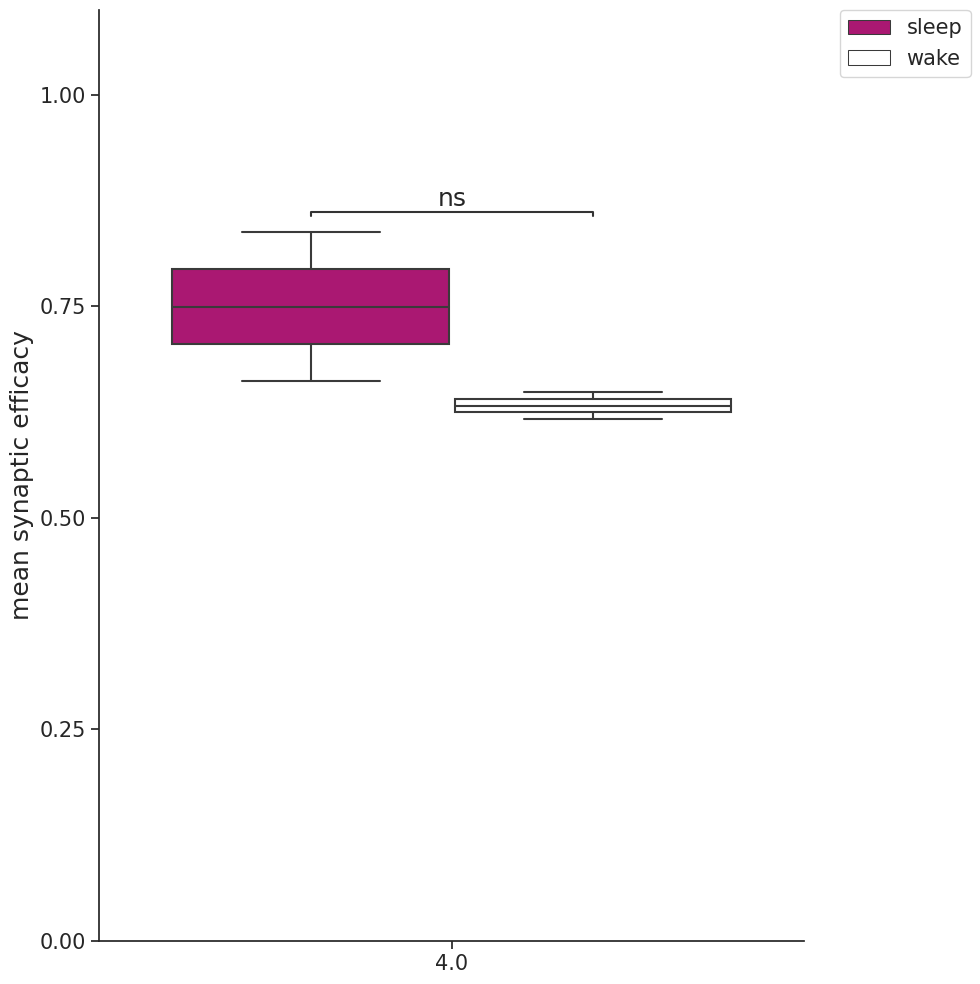

In [6]:
# comparing sleep and wake by learning rules

model_pre = "AN"

op="_net_effi"
bifur = "nmdar"
lr_p = "a0.7t50th0.6"
NE = 64
Ip = 20
NI = int(NE*Ip/(100-Ip))
N=NE+NI
con_log=True




lr_li = ["Hebbian", "Anti-Hebbian", "STDP", "Anti-STDP"]
sw = ["sleep", "wake"]
fs = 18
fs_l = 15
Hz="4.0"

colors =[sns.xkcd_rgb["orange"], sns.xkcd_rgb["blue"], sns.xkcd_rgb["magenta"], sns.xkcd_rgb["green"]]

# colors =[sns.xkcd_rgb["magenta"]]
# plt.figure(figsize=(24,15))


for m, lr in enumerate(lr_li):
    if m!=2:
        continue
        
    model_name = model_pre + op + "_"+bifur +"_"+lr +"_w"
    model_name_s = model_pre + op +"_"+ bifur +"_"+lr +"_s"

    sdir = rdir +  "/net_lr/"
    T_dir = sdir + "{}{}_{}_N{}_{}_{}/".format(model_pre, op, bifur, NE+NI, lr, lr_p)
    print(T_dir)

    
    dsb_w = T_dir+"/wake.csv"
    dsb_s = T_dir+"/sleep.csv"
    synv_w= np.genfromtxt(dsb_w, delimiter=",", dtype=np.float64)
    print("wake", lr,  len(synv_w), np.mean(synv_w,axis = 0))
    synv_s= np.genfromtxt(dsb_s, delimiter=",", dtype=np.float64)
    print("sleep", lr,  len(synv_s), np.mean(synv_s,axis = 0))

    df_w = pd.DataFrame(synv_w, columns=["order","mean_effi"])
    df_s = pd.DataFrame(synv_s, columns=["order","mean_effi"])
    df_w["lr"] = lr
    df_s["lr"] = lr
    df_w["state"] = "wake"
    df_s["state"] = "sleep"
    
    df_s["Hz"] = Hz
    df_w["Hz"] = Hz
    
    #print(df)

#             if l==0 and n==0:
#                 dfs = df
#             else:
    dfs = pd.concat([df_s, df_w])
    print("number of samples: ", len(df_s))

    plt.figure(figsize=(10,10))
    
    x = "Hz"
    y = "mean_effi"
    hue = "state"
    hue_order = sw
    ax = sns.boxplot(data=dfs,palette=[colors[m], sns.xkcd_rgb["white"]], x=x, y=y, hue=hue)
    add_stat_annotation(ax, data=dfs, x=x, y=y, hue=hue,comparisons_correction=None,

                                         box_pairs = [(('4.0',"sleep"), ('4.0', "wake"))
                                                     ],
                                       
                        test='t-test_ind', text_format='star', loc='outside', fontsize=fs, verbose=2)

    plt.yticks(fontsize = fs_l)
    plt.xticks(fontsize = fs_l)
    ax.set_yticks(np.arange(0,1.1,0.25))
    ax.set_ylim(0, 1.1)

    plt.ylabel("mean synaptic efficacy", fontsize = fs)
    plt.xlabel("", fontsize = fs)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.grid(False)
   
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=fs_l)
    plt.tight_layout()
    
    
    plt.savefig( "boxplot_{}_{}_N{}_{}_{}.SVG".format( model_pre, bifur, N, lr, lr_p))
    plt.show()

./net_lr/SANAGNca_NaK1_log_lrex_net_min2_nmdar_N80_Anti-STDP_a0.7t50th0.6/
wake Anti-STDP 121 [0.         0.45400792]
sleep Anti-STDP 121 [0.         0.49242461]
number of samples:  121
p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

4.0_sleep v.s. 4.0_wake: t-test independent samples, P_val=8.212e-02 stat=1.746e+00


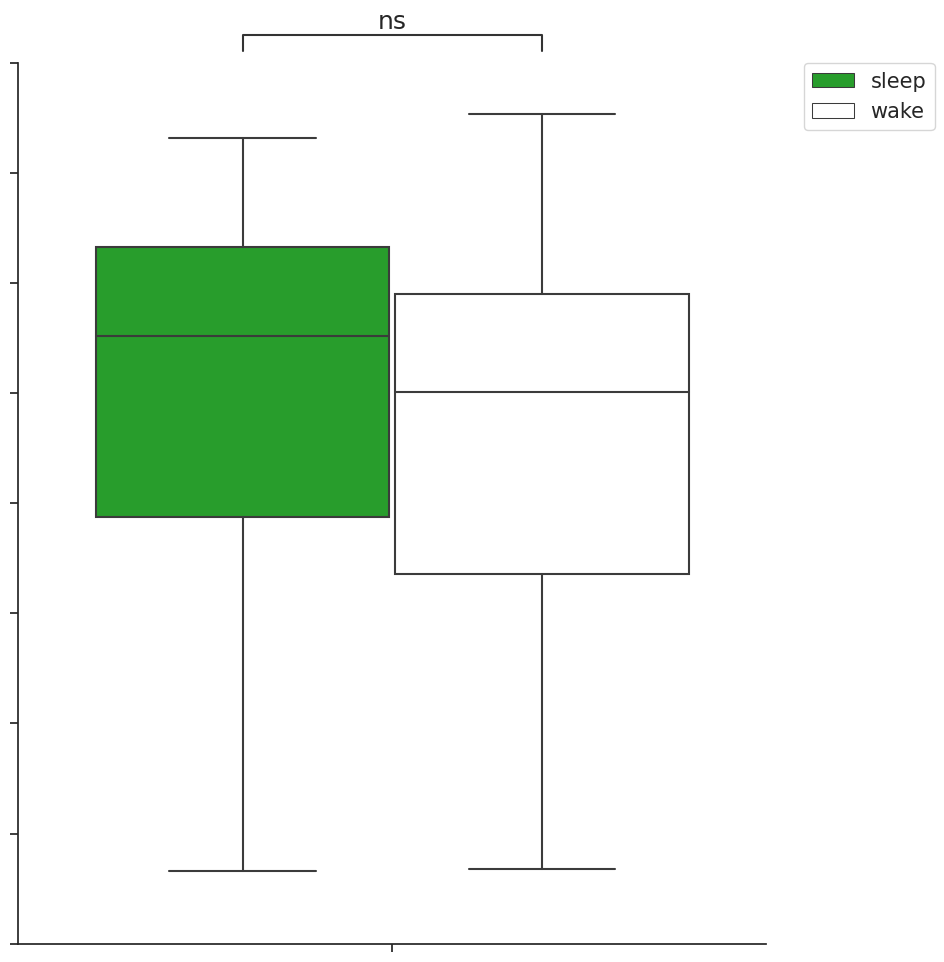

In [23]:
# comparing sleep and wake by learning rules  #CV

model_pre = "AN"
op="_net_effi"
bifur = "nmdar"

lr_p = "a0.7t50th0.6"
NE = 64
Ip = 20
NI = int(NE*Ip/(100-Ip))
N=NE+NI
con_log=True



lr_li =["Hebbian", "Anti-Hebbian", "STDP", "Anti-STDP"]
sw = ["sleep", "wake"]
fs = 18
fs_l = 15
Hz="4.0"

colors =[sns.xkcd_rgb["orange"], sns.xkcd_rgb["blue"], sns.xkcd_rgb["magenta"], sns.xkcd_rgb["green"]]


for m, lr in enumerate(lr_li):
    if m!=3:
        continue
    
    model_name = model_pre + op + "_" + bifur +"_"+lr +"_w"
    model_name_s = model_pre + op + "_" + bifur +"_"+lr +"_s"

    sdir = rdir + "/net_lr/"
    T_dir = sdir + "{}{}_{}_N{}_{}_{}/".format(model_pre, op, bifur, NE+NI, lr, lr_p)
    print(T_dir)

    dsb_w = T_dir+"/wake_cv.csv"
    dsb_s = T_dir+"/sleep_cv.csv"
    synv_w= np.genfromtxt(dsb_w, delimiter=",", dtype=np.float64)
    print("wake", lr,  len(synv_w), np.mean(synv_w,axis = 0))
    synv_s= np.genfromtxt(dsb_s, delimiter=",", dtype=np.float64)
    print("sleep", lr,  len(synv_s), np.mean(synv_s,axis = 0))

    df_w = pd.DataFrame(synv_w, columns=["order","CV"])
    df_s = pd.DataFrame(synv_s, columns=["order","CV"])
    df_w["lr"] = lr
    df_s["lr"] = lr
    df_w["state"] = "wake"
    df_s["state"] = "sleep"
    
    df_s["Hz"] = Hz
    df_w["Hz"] = Hz
    

    dfs = pd.concat([df_s, df_w])
    print("number of samples: ", len(df_s))

    plt.figure(figsize=(10,10))
    
    x = "Hz"
    y = "CV"
    hue = "state"
    hue_order = sw
    ax = sns.boxplot(data=dfs,palette=[colors[m], sns.xkcd_rgb["white"]], x=x, y=y, hue=hue)
    add_stat_annotation(ax, data=dfs, x=x, y=y, hue=hue,comparisons_correction=None,

                                         box_pairs = [(('4.0',"sleep"), ('4.0', "wake"))
                                                     ],
                                       
                        test='t-test_ind', text_format='star', loc='outside', fontsize=fs, verbose=2)

    
    plt.ylim(0., 0.8)
    plt.yticks(fontsize = fs_l)
    plt.xticks(fontsize = fs_l)
#     ax.set_yticks(np.arange(0,1.1,0.25))
#     ax.set_ylim(0, 1.1)

    plt.ylabel("CV of synaptic efficacy", fontsize = fs)
    plt.xlabel("", fontsize = fs)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.grid(False)
   
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=fs_l)
    plt.tight_layout()
    
    plt.savefig("boxplot_{}_{}_N{}_{}_{}_CV.SVG".format( model_pre, bifur, N, lr, lr_p))
  
    plt.show()

[(('0-4Hz', 'sleep'), ('0-4Hz', 'wake')), (('4-8Hz', 'sleep'), ('4-8Hz', 'wake')), (('8-12Hz', 'sleep'), ('8-12Hz', 'wake'))]
./net_lr/SANAGNca_NaK1_log_lrex_net_min2_nmdar_N80_STDP_a0.7t50th0.6/
wake STDP 35 [0.14285714 0.63995355]
sleep STDP 35 [0.14285714 0.73329424]
    order  mean_effi    lr  state     Hz
0     0.0   0.839685  STDP  sleep  0-4Hz
1     0.0   0.601004  STDP  sleep  0-4Hz
2     0.0   0.718233  STDP  sleep  0-4Hz
3     2.0   0.771005  STDP  sleep  0-4Hz
4     0.0   0.691970  STDP  sleep  0-4Hz
..    ...        ...   ...    ...    ...
30    0.0   0.718542  STDP   wake  0-4Hz
31    1.0   0.833694  STDP   wake  0-4Hz
32    0.0   0.687890  STDP   wake  0-4Hz
33    0.0   0.712196  STDP   wake  0-4Hz
34    0.0   0.543830  STDP   wake  0-4Hz

[70 rows x 5 columns]
wake STDP 106 [0.20754717 0.64726296]
sleep STDP 106 [0.20754717 0.74076575]
     order  mean_effi    lr  state     Hz
0      0.0   0.721422  STDP  sleep  4-8Hz
1      0.0   0.685787  STDP  sleep  4-8Hz
2      0.0 

ValueError: box_pairs contains an invalid box pair.

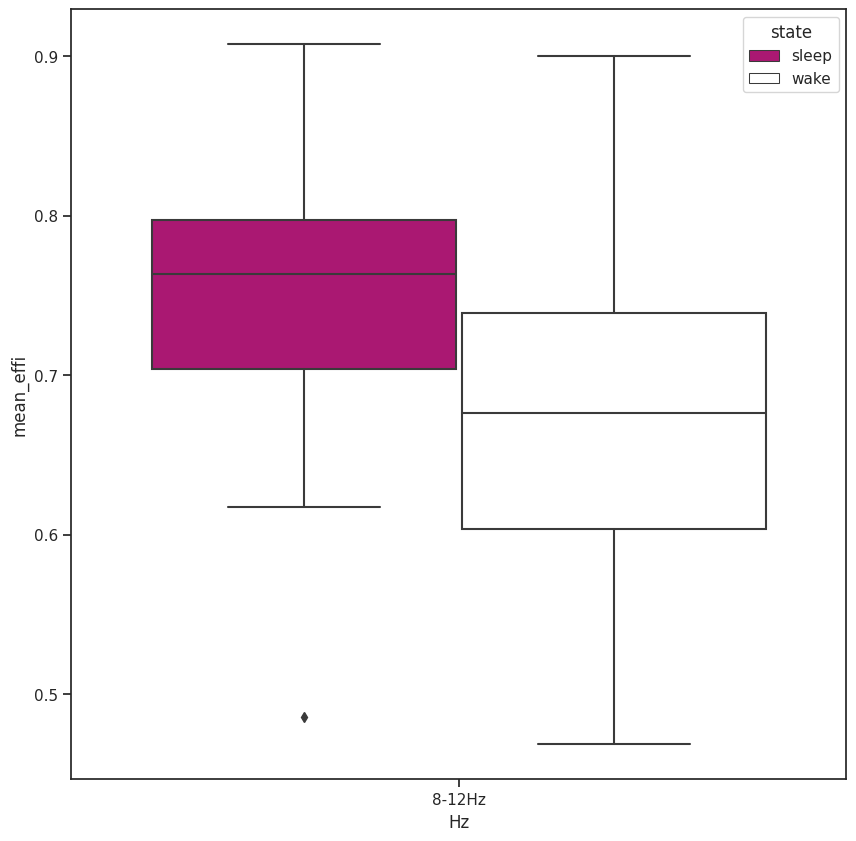

In [18]:
# comparing sleep and wake by learning rules by Hz

model_pre = "AN"

op="_net_effi"
bifur = "nmdar"
lr_p = "a0.7t50th0.6"

Hz_li = ["0-4Hz","4-8Hz", "8-12Hz"]
Hz_rs = [[0,4], [4,8], [8,12]]


NE = 64
Ip = 20
NI = int(NE*Ip/(100-Ip))
N=NE+NI
con_log=True


lr_li =["Hebbian", "Anti-Hebbian", "STDP", "Anti-STDP"]
sw = ["sleep", "wake"]
fs = 18
fs_l = 15

colors =[sns.xkcd_rgb["orange"], sns.xkcd_rgb["blue"], sns.xkcd_rgb["magenta"], sns.xkcd_rgb["green"]]
box_pairs = []
for h, Hz in enumerate(Hz_li):
    pair_sw = []
    for i, sw_i in enumerate(sw):
        pair_sw.append((Hz, sw_i))
    box_pairs.append((pair_sw[0], pair_sw[1]))
    

print(box_pairs)

# colors =[sns.xkcd_rgb["magenta"]]
# plt.figure(figsize=(24,15))
dfs2=[]
num_li=[]

for m, lr in enumerate(lr_li):
    if m!=2:
        continue

    model_name = model_pre + op + "_"+bifur +"_"+lr +"_w"
    model_name_s = model_pre + op +"_" +bifur +"_"+lr +"_s"

    sdir = rdir + "/net_lr/"
    T_dir = sdir + "{}{}_{}_N{}_{}_{}/".format(model_pre, op, bifur, NE+NI, lr, lr_p)
    print(T_dir)

    for h, Hz in enumerate(Hz_li):

        dsb_w = T_dir+"wake_{}.csv".format(Hz)
        dsb_s = T_dir+"sleep_{}.csv".format(Hz)
        synv_w= np.genfromtxt(dsb_w, delimiter=",", dtype=np.float64)
        print("wake", lr,  len(synv_w), np.mean(synv_w,axis = 0))
        synv_s= np.genfromtxt(dsb_s, delimiter=",", dtype=np.float64)
        print("sleep", lr,  len(synv_s), np.mean(synv_s,axis = 0))

        df_w = pd.DataFrame(synv_w, columns=["order","mean_effi"])
        df_s = pd.DataFrame(synv_s, columns=["order","mean_effi"])
        df_w["lr"] = lr
        df_s["lr"] = lr
        df_w["state"] = "wake"
        df_s["state"] = "sleep"

        df_s["Hz"] = Hz
        df_w["Hz"] = Hz

        #print(df)

    #             if l==0 and n==0:
    #                 dfs = df
    #             else:
        num_li.append(len(df_s))
        dfs = pd.concat([df_s, df_w])
        print(dfs)
        dfs2.append(dfs)
        
    dfs_all=pd.concat(dfs2, axis=0)


    plt.figure(figsize=(10,10))

    x = "Hz"
    y = "mean_effi"
    hue = "state"
    hue_order = sw
    ax = sns.boxplot(data=dfs_all,palette=[colors[m], sns.xkcd_rgb["white"]], x=x, y=y, hue=hue)
    add_stat_annotation(ax, data=dfs_all, x=x, y=y, hue=hue,comparisons_correction=None,

                                         box_pairs = box_pairs,

                            test='t-test_ind', text_format='star', loc='outside', fontsize=fs, verbose=2)

    plt.yticks(fontsize = fs_l)
    plt.xticks(fontsize = fs)
    ax.set_yticks(np.arange(0,1.1,0.25))
    ax.set_ylim(0, 1.1)

    plt.ylabel("mean synaptic efficacy", fontsize = fs)
    plt.xlabel("Hz", fontsize = fs)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.grid(False)

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=fs_l)
    plt.tight_layout()

    plt.savefig( "boxplot_{}_{}_N{}_{}_{}_Hz.SVG".format( model_pre, bifur, N, lr, lr_p))
    plt.show()

    print("number of samples by Hz:",num_li )

[(('0-4Hz', 'sleep'), ('0-4Hz', 'wake')), (('4-8Hz', 'sleep'), ('4-8Hz', 'wake')), (('8-12Hz', 'sleep'), ('8-12Hz', 'wake'))]
./net_lr/SANAGNca_NaK1_log_lrex_net_min2_nmdar_N80_STDP_a0.7t50th0.6/
wake STDP 35 [0.14285714 0.63995355]
sleep STDP 35 [0.14285714 0.73329424]
    order        CV    lr  state     Hz
0     0.0  0.839685  STDP  sleep  0-4Hz
1     0.0  0.601004  STDP  sleep  0-4Hz
2     0.0  0.718233  STDP  sleep  0-4Hz
3     2.0  0.771005  STDP  sleep  0-4Hz
4     0.0  0.691970  STDP  sleep  0-4Hz
..    ...       ...   ...    ...    ...
30    0.0  0.718542  STDP   wake  0-4Hz
31    1.0  0.833694  STDP   wake  0-4Hz
32    0.0  0.687890  STDP   wake  0-4Hz
33    0.0  0.712196  STDP   wake  0-4Hz
34    0.0  0.543830  STDP   wake  0-4Hz

[70 rows x 5 columns]
wake STDP 106 [0.20754717 0.64726296]
sleep STDP 106 [0.20754717 0.74076575]
     order        CV    lr  state     Hz
0      0.0  0.721422  STDP  sleep  4-8Hz
1      0.0  0.685787  STDP  sleep  4-8Hz
2      0.0  0.640683  STDP

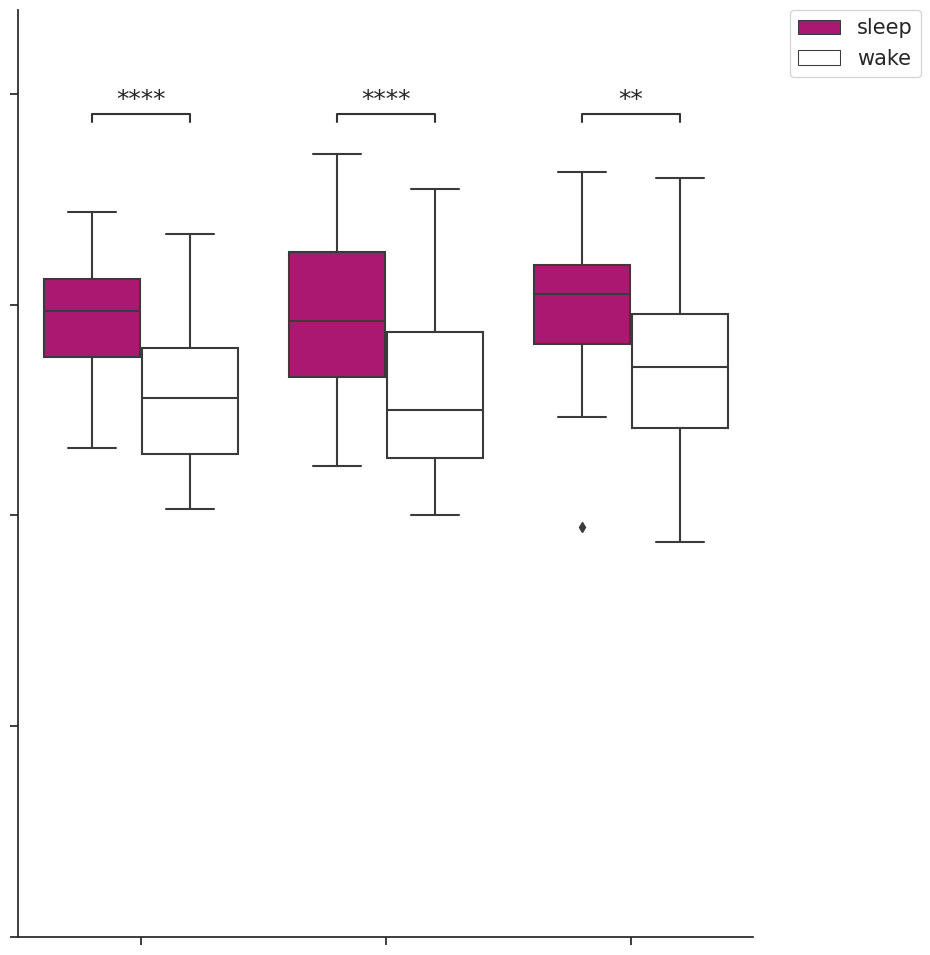

number of samples by Hz: [35, 106, 29]


In [22]:
# comparing sleep and wake by learning rules by Hz   CV

model_pre = "AN"

op="_net_effi"
bifur = "nmdar"
lr_p = "a0.7t50th0.6"

Hz_li = ["0-4Hz","4-8Hz", "8-12Hz"]
Hz_rs = [[0,4], [4,8], [8,12]]


NE = 64
Ip = 20
NI = int(NE*Ip/(100-Ip))
N=NE+NI
con_log=True


lr_li =["Hebbian", "Anti-Hebbian", "STDP", "Anti-STDP"]
sw = ["sleep", "wake"]
fs = 18
fs_l = 15


colors =[sns.xkcd_rgb["orange"], sns.xkcd_rgb["blue"], sns.xkcd_rgb["magenta"], sns.xkcd_rgb["green"]]
box_pairs = []
for h, Hz in enumerate(Hz_li):
    pair_sw = []
    for i, sw_i in enumerate(sw):
        pair_sw.append((Hz, sw_i))
    box_pairs.append((pair_sw[0], pair_sw[1]))
    

print(box_pairs)

# colors =[sns.xkcd_rgb["magenta"]]
# plt.figure(figsize=(24,15))
dfs2=[]
num_li=[]

for m, lr in enumerate(lr_li):
    if m!=2:
        continue

    model_name = model_pre + op + "_"+bifur +"_"+lr +"_w"
    model_name_s = model_pre + op +"_" +bifur +"_"+lr +"_s"

    sdir = rdir + "/net_lr/"
    T_dir = sdir + "{}{}_{}_N{}_{}_{}/".format(model_pre, op, bifur, NE+NI, lr, lr_p)
    print(T_dir)

    for h, Hz in enumerate(Hz_li):

        dsb_w = T_dir+"wake_{}_cv.csv".format(Hz)
        dsb_s = T_dir+"sleep_{}_cv.csv".format(Hz)
        synv_w= np.genfromtxt(dsb_w, delimiter=",", dtype=np.float64)
        print("wake", lr,  len(synv_w), np.mean(synv_w,axis = 0))
        synv_s= np.genfromtxt(dsb_s, delimiter=",", dtype=np.float64)
        print("sleep", lr,  len(synv_s), np.mean(synv_s,axis = 0))

        df_w = pd.DataFrame(synv_w, columns=["order","CV"])
        df_s = pd.DataFrame(synv_s, columns=["order","CV"])
        df_w["lr"] = lr
        df_s["lr"] = lr
        df_w["state"] = "wake"
        df_s["state"] = "sleep"

        df_s["Hz"] = Hz
        df_w["Hz"] = Hz

        #print(df)

    #             if l==0 and n==0:
    #                 dfs = df
    #             else:
        num_li.append(len(df_s))
        dfs = pd.concat([df_s, df_w])
        print(dfs)
        dfs2.append(dfs)
        
    dfs_all=pd.concat(dfs2, axis=0)


    plt.figure(figsize=(10,10))

    x = "Hz"
    y = "CV"
    hue = "state"
    hue_order = sw
    ax = sns.boxplot(data=dfs_all,palette=[colors[m], sns.xkcd_rgb["white"]], x=x, y=y, hue=hue)
    add_stat_annotation(ax, data=dfs_all, x=x, y=y, hue=hue,comparisons_correction=None,
    #                                        box_pairs=[(('Hebbian',"wake"),('Anti-Hebbian',"wake")), (('Hebbian',"sleep"),('Anti-Hebbian',"sleep")),
    #                                                   (('STDP',"wake"), ('Anti-STDP', "wake")), (('STDP',"sleep"), ('Anti-STDP', "sleep")),
    #                                                   (('STDP',"wake"), ('STDP', "sleep")), (('Anti-STDP',"wake"), ('Anti-STDP', "sleep")) ],#lr_coms,
    #                                        box_pairs= pairs,
    #                                               [(('0.10',"wake"),('0.10',"sleep")), (('0.30',"wake"),('0.30',"sleep")),
    #                                                   (('1.0',"wake"), ('1.0', "sleep")), (('3.0',"wake"), ('3.0', "sleep")), #(('10.0',"wake"), ('10.0', "sleep"))
    #                                                    ],#lr_coms,
                                         box_pairs = box_pairs,

                            test='t-test_ind', text_format='star', loc='outside', fontsize=fs, verbose=2)

    plt.yticks(fontsize = fs_l)
    plt.xticks(fontsize = fs)
    ax.set_yticks(np.arange(0,1.1,0.25))
    ax.set_ylim(0, 1.1)

    plt.ylabel("CV of synaptic efficacy", fontsize = fs)
    plt.xlabel("Hz", fontsize = fs)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.grid(False)

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=fs_l)
    plt.tight_layout()

    plt.savefig( "boxplot_{}_{}_N{}_{}_{}_Hz_CV.SVG".format( model_pre, bifur, N, lr, lr_p))
    plt.show()

    print("number of samples by Hz:",num_li )